In [2]:
import json
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path

import fastplot
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

from aspa_verification import ASPAVerifier

%matplotlib inline

In [3]:
### SETUP

# Set to True if you have LaTeX locally installed and want to use it for plotting.
COMPILE_LATEX = True

if COMPILE_LATEX:
    plot_style = 'latex'
else:
    plot_style = 'sans-serif'

# Find route leaks

Running this section of the notebook requires downloading and processing a 40 GB file from containing all paths observed across the midnight dumps of all RIPE NCC and RouteViews RRCs between March 1st and 5th.
From this file, AS Paths are extracted and processed as follows:
- Compress each path
- Extract all subpaths
- Keep only paths with 3 or more ASes

Paths are then validated according to the algorithm presented in the paper, and invalid paths are saved to `data/2026-03-invalid-paths.txt` for further analyses.

---

To reproduce the results, you must first run `python get_caida_data.py --paths`, which will:
- Download a 2 GB file;
- Unzip it to a 40 GB file (`data/caida/2026-03-paths.txt`);
- Extract paths into `data/caida/2026-03-paths.txt`.

On older systems, this might take a couple of hours.
Processed paths are then stored in `AS_paths.txt`

In [4]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = df.set_index('asn_customer')['providers'].apply(lambda prov: set(prov.replace('AS', '').split(' '))).to_dict()

In [5]:
PATHS_PROCESSED = Path("AS_paths.txt")
PATHS_UNPROCESSED = Path("data/caida/2026-03-paths.txt")

def load_as_paths():
    all_paths = set()
    with PATHS_PROCESSED.open("r") as f:
        for line in f:
            path_str = line.strip()
            all_paths.add(path_str)

    return all_paths

def compress(path):
    result = [path[0]]
    for asn in path[1:]:
        if asn != result[-1]:
            result.append(asn)

    return result

def build_as_paths():
    all_paths = set()

    with PATHS_UNPROCESSED.open("r") as f:
        for line in f:
            path_str = line.strip()
            path = compress(path_str.split("|"))
            
            for i in range(len(path) - 2):
                subpath = '|'.join(path[i:])
                all_paths.add(subpath)

    with PATHS_PROCESSED.open("w") as f:
        for p in all_paths:
            f.write(p + "\n")
            
    return all_paths

if PATHS_PROCESSED.exists():
    print("AS_paths.txt found, loading paths...")
    all_paths = load_as_paths()
elif PATHS_UNPROCESSED.exists():
    print("Processing 2026-03-paths.txt, saving to AS_paths.txt...")
    all_paths = build_as_paths()
else:
    print("Downloading CAIDA data...")
    subprocess.run([sys.executable, "get_caida_data.py", "--paths"], check=True)
    all_paths = build_as_paths()

print(f"Loaded {len(all_paths)} paths")

AS_paths.txt found, loading paths...
Loaded 56708620 paths


In [6]:
# ~15 minutes

verifier = ASPAVerifier(aspa)

data = defaultdict(set)

outcome_by_tactic = {
    'upstream': Counter(),
    'fallback': Counter()
}

uncertain_outcomes = Counter()

# paths are already compressed and filtered from the pre-proccesing
for path_str in tqdm(all_paths):

    path = path_str.split('|')

    receiver = path[0]
    neighbor = path[1]
    received_path = path[1:]

    outcome = 'N/A'
    
    if receiver in aspa and neighbor not in aspa[receiver]:
        outcome = verifier.verify_upstream_path(received_path)
        outcome_by_tactic['upstream'][outcome] += 1
    else:
        o1 = verifier.verify_upstream_path(received_path)
        o2 = verifier.verify_downstream_path(received_path)

        if o1 == "Invalid" and o2 == "Invalid":
            outcome = "Invalid"
        elif o1 == "Unknown" and o2 == "Unknown":
            outcome = "Unknown"
        elif o1 == "Valid" and o2 == "Valid":
            outcome = "Valid"

        outcome_by_tactic['fallback'][outcome] += 1

        if outcome == "N/A":
            uncertain_outcomes[(o1, o2)] += 1

    data[outcome].add(path_str)

  0%|          | 0/56708620 [00:00<?, ?it/s]

100%|██████████| 56708620/56708620 [04:19<00:00, 218788.12it/s]


In [7]:
outcome_by_tactic

{'upstream': Counter({'Unknown': 2826034, 'Valid': 26211, 'Invalid': 13956}),
 'fallback': Counter({'Unknown': 39799746,
          'N/A': 13814343,
          'Valid': 205631,
          'Invalid': 22699})}

In [8]:
uncertain_outcomes

Counter({('Unknown', 'Valid'): 7628944,
         ('Invalid', 'Unknown'): 6052607,
         ('Invalid', 'Valid'): 132792})

In [9]:
tot = sum(len(v) for v in data.values())
for k, v in data.items():
    print(k, f'{len(v)} ({len(v) / tot * 100:.2f}%)')

Unknown 42625780 (75.17%)
N/A 13814343 (24.36%)
Valid 231842 (0.41%)
Invalid 36655 (0.06%)


In [10]:
with open('data/2026-03-invalid-paths.txt', 'w') as f:
    for path in data['Invalid']:
        f.write(f'{path}\n')

In [11]:
with open('data/2026-03-NA-paths.txt', 'w') as f:
    for path in data['N/A']:
        f.write(f'{path}\n')

In [ ]:
import pickle

with open('data/outcome-paths.pickle', 'wb') as f:
    pickle.dump(data, f)

# Solving N/A paths through inferred relationships

In [12]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = df.set_index('asn_customer')['providers'].apply(lambda prov: set(prov.replace('AS', '').split(' '))).to_dict()
verifier = ASPAVerifier(aspa)

In [13]:
na_paths = set()

with open('data/2026-03-NA-paths.txt', 'r') as f:
    for line in f:
        path_str = line.strip()
        na_paths.add(path_str)

## BGPKIT AS Rel

In [14]:
_bgpkit_prov_list = []

for day in ('01', '02', '03', '04', '05'):
    _bgpkit_prov = (
        pd
            .read_json(f'data/bgpkit/as-rel_2026-03-{day}.json', dtype={'asn1': str, 'asn2': str})
            [['asn1', 'asn2', 'rel']]
            .rename(columns={'asn1': 'provider', 'asn2': 'customer'})
            .query('rel != 0')
            .groupby('customer')
            ['provider']
            .agg(set)
            .to_dict()
    )
    _bgpkit_prov_list.append(_bgpkit_prov)

bgpkit_prov = defaultdict(set)
for d in _bgpkit_prov_list:
    for customer, providers in d.items():
        bgpkit_prov[customer] |= providers

In [ ]:
na_infer_outcomes = Counter()

for path_str in na_paths:
    path = path_str.split('|')
    receiver = path[0]
    neighbor = path[1]

    if neighbor in bgpkit_prov[receiver] and receiver in bgpkit_prov[neighbor]:
        # complex relationships, cannot infer direction of path
        na_infer_outcomes['complex'] += 1
        continue

    if neighbor in bgpkit_prov[receiver] and receiver not in bgpkit_prov[neighbor]:
        # Neighbor is inferred as a provider of receiver
        # Receiver is *not* inferred as a provider of neighbor
        # Path is going down
        verification = verifier.verify_downstream_path(path[1:])
    else:
        # Neighbor is either a peer or a customer
        # Path is going up
        verification = verifier.verify_upstream_path(path[1:])

    na_infer_outcomes[verification] += 1

In [16]:
for k, v in na_infer_outcomes.items():
    print(k, f'{v} ({v / sum(na_infer_outcomes.values()) * 100:.1f}%)')

Unknown 10014537 (72.5%)
Valid 3398401 (24.6%)
Invalid 251845 (1.8%)
complex 149560 (1.1%)


## CAIDA AS Rel

In [17]:
_caida_prov_4 = (
    pd
        .read_csv('data/caida/2026-03-as-rel-v4.txt', 
                             sep='|', comment='#', header=None,  
                             names=['provider', 'customer', 'rel'],
                             dtype={'provider': str, 'customer': str, 'rel': int}
                 )
        .query('rel != 0')
        .groupby('customer')
        ['provider']
        .agg(set)
        .to_dict()
)

_caida_prov_6 = (
    pd
        .read_csv('data/caida/2026-03-as-rel-v6.txt', 
                             sep='|', comment='#', header=None,  
                             names=['provider', 'customer', 'rel'],
                             dtype={'provider': str, 'customer': str, 'rel': int}
                 )
        .query('rel != 0')
        .groupby('customer')
        ['provider']
        .agg(set)
        .to_dict()
)

caida_prov = defaultdict(set)
for customer, providers in _caida_prov_4.items():
    caida_prov[customer] |= providers

for customer, providers in _caida_prov_6.items():
    caida_prov[customer] |= providers

In [18]:
na_infer_outcomes = Counter()

for path_str in na_paths:
    path = path_str.split('|')
    receiver = path[0]
    neighbor = path[1]

    if neighbor in caida_prov[receiver] and receiver in caida_prov[neighbor]:
        # complex relationships, skip to be safe
        na_infer_outcomes['complex'] += 1
        continue

    if neighbor in caida_prov[receiver] and receiver not in caida_prov[neighbor]:
        # Neighbor is inferred as a provider of receiver
        # Receiver is *not* inferred as a provider of neighbor
        # Path is going down
        verification = verifier.verify_downstream_path(path[1:])
    else:
        # Neighbor is either a peer or a customer
        # Path is going up
        verification = verifier.verify_upstream_path(path[1:])

    na_infer_outcomes[verification] += 1

In [19]:
for k, v in na_infer_outcomes.items():
    print(k, f'{v} ({v / sum(na_infer_outcomes.values()) * 100:.1f}%)')

Unknown 10972644 (79.4%)
Valid 2459495 (17.8%)
Invalid 381258 (2.8%)
complex 946 (0.0%)


# Validating route leaks

- Verify whether the invalid paths we identified appear within Cloudflare's dataset of detected route leaks 
- Data source: https://developers.cloudflare.com/api/resources/radar/subresources/bgp/subresources/leaks/subresources/events/methods/list
- Script: `python get_cloudflare_routeleaks.py <TOKEN>`
- Token: `cfat_vw4muMQhedSNwI6gdDRVJodzAJr40OvvEQF0MckQa0491f08`

In [25]:
cloudflare_leaks_data = dict()
with open('data/cloudflare_routeleaks.json', 'r') as f:
    cloudflare_leaks_data = json.load(f)

invalid_paths = set()
with open('data/2026-03-invalid-paths.txt', 'r') as f:
    for line in f:
        invalid_paths.add(f'|{line.strip()}|')

cloudflare_leaks = set()
for leak_event in cloudflare_leaks_data:
    leak_seg = [str(asn) for asn in leak_event['leak_seg']]
    leak_str = f'|{"|".join(leak_seg)}|'
    cloudflare_leaks.add(leak_str)

print(f"Cloudflare leaks: {len(cloudflare_leaks)}")
print(f"Invalid paths identified by us: {len(invalid_paths)}")

Cloudflare leaks: 730
Invalid paths identified by us: 36655


In [26]:
matched_cloudflare_leaks_paths = defaultdict(set)

for leak_str in cloudflare_leaks:
    for path_str in invalid_paths:
        if leak_str in path_str:
            matched_cloudflare_leaks_paths[leak_str].add(path_str)

print(f"Matched Cloudflare leaks: {len(matched_cloudflare_leaks_paths)}")
print(f"They cover {sum(len(v) for v in matched_cloudflare_leaks_paths.values())} of our invalid paths")

Matched Cloudflare leaks: 29
They cover 657 of our invalid paths


# Minimal invalid paths
Analysis of Minimal Invalid Paths (MIPs) from which the 36655 invalid paths stem.

In [27]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = df.set_index('asn_customer')['providers'].apply(lambda prov: set(prov.replace('AS', '').split(' '))).to_dict()
verifier = ASPAVerifier(aspa)

invalid_paths = set()
with open('data/2026-03-invalid-paths.txt', 'r') as f:
    for line in f:
        invalid_paths.add(line.strip())

In [28]:
# Find minimal invalid paths (MIPs), i.e., the set of smallest (unique) invalid subpath across all 36k invalid paths
# The MIP includes the receiving / verifying AS
mip = set()
mip_data = defaultdict(set)

for path_str in invalid_paths:
    path = path_str.split('|')

    offset = 0 # CHANGED: from 1 to 0

    while offset < len(path) - 1: # CHANGED: from len(path) - 2 to len(path) - 1 to include invalid paths of length 3
        subpath = path[offset:]
        
        receiver = subpath[0]
        neighbor = subpath[1]
        received_path = subpath[1:]
        
        outcome = 'N/A'
        
        if receiver in aspa and neighbor not in aspa[receiver]:
            outcome = verifier.verify_upstream_path(received_path)
        else:
            o1 = verifier.verify_upstream_path(received_path)
            o2 = verifier.verify_downstream_path(received_path)
            
            if o1 == "Invalid" and o2 == "Invalid":
                outcome = "Invalid"
        
        if outcome != "Invalid":
            root = path[offset - 1:]
            root_str = '|'.join(path[(offset - 1):])
            mip.add(root_str)
            mip_data[root_str].add(path_str)
            break
        
        offset += 1

print(f'MIPs: {len(mip)}')

MIPs: 13406


In [30]:
mip_sources = Counter()
mip_presence = Counter()

for mip_str in mip:
    path = mip_str.split('|')
    mip_sources[path[-1]] += 1
    for asn in path[1:]:
        mip_presence[asn] += 1

print(f"MIPs are originated by {len(mip_sources)} ASes")
print(f"Of which {sum(1 for asn in mip_sources if asn in aspa)} have a valid ASPA")
print(mip_sources.most_common(5))

print(f"ASes found in MIPs: {len(mip_presence)}")
print(mip_presence.most_common(5))

MIPs are originated by 3818 ASes
Of which 490 have a valid ASPA
[('61574', 210), ('271150', 106), ('2716', 83), ('61625', 82), ('48595', 56)]
ASes found in MIPs: 4404
[('6939', 6779), ('1299', 2684), ('57463', 1825), ('12735', 1780), ('52091', 1141)]


In [31]:
mips_len = Counter()

for mip_str in mip:
    path = mip_str.split('|')
    n = len(path)
    mips_len[n] += 1

print(mips_len.most_common())

[(4, 5822), (5, 4392), (3, 1482), (6, 1222), (7, 351), (8, 105), (9, 29), (19, 1), (10, 1), (11, 1)]


In [33]:
# to how many ASes each MIP is directly propagated?
mip_propagated_to_direct = defaultdict(set)
mip_propagated_to_all = defaultdict(set)

for mip_str, full_invalid_paths in mip_data.items():
    # mip_data is a dict: key is the MIP, value is the set of all invalid paths that share that MIP
    mip_path = mip_str.split('|')
    for path_str in full_invalid_paths:
        path = path_str.split('|')
        suffix_path = path[:-len(mip_path)]
        if len(suffix_path) > 0:
            mip_propagated_to_direct[mip_str].add(suffix_path[-1])
            for asn in suffix_path:
                mip_propagated_to_all[mip_str].add(asn)
        else:
            # the MIP is not propagated at all
            continue


direct_propagation_counter = Counter()
# add as many zeros as the number of MIPs that are not propagated at all
plot_data_direct = [0] * (len(mip) - len(mip_propagated_to_direct))
for _mip, propagated_to in mip_propagated_to_direct.items():
    direct_propagation_counter[len(propagated_to)] += 1
    plot_data_direct.append(len(propagated_to))

indirect_propagation_counter = Counter()
# add as many zeros as the number of MIPs that are not propagated at all
plot_data_all = [0] * (len(mip) - len(mip_propagated_to_all))
for _mip, propagated_to in mip_propagated_to_all.items():
    indirect_propagation_counter[len(propagated_to)] += 1
    plot_data_all.append(len(propagated_to))

<Figure size 640x480 with 0 Axes>

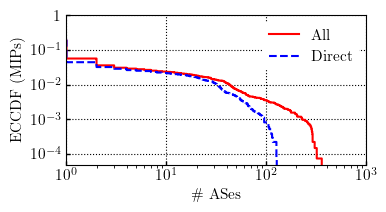

In [43]:
def callback(plt):
    ax = plt.gca()

    ax.ecdf(plot_data_all, complementary=True, label='All')
    ax.ecdf(plot_data_direct, complementary=True, label='Direct')

    ax.set_xscale('log')
    ax.set_yscale('log')
    legend = ax.legend(fancybox=False, frameon=True, loc='upper right')
    legend.get_frame().set_linewidth(0.0)
    legend.get_frame().set_alpha(1)

    ax.grid(True, which="major", ls="dotted", color='k')
    ax.set_ylim(5 * 10e-6, 1)
    ax.set_xlabel(r'\# ASes')
    ax.set_ylabel('ECCDF (MIPs)')

    ax.set_yticks([1, 0.1, 0.01, 0.001, 0.0001])
    ax.set_yticklabels(['1', '$10^{-1}$', '$10^{-2}$', '$10^{-3}$', '$10^{-4}$'])


fastplot.plot(None, None, mode='callback', callback=callback, style=plot_style)

plt.savefig('figures/mip_propagation.pdf', bbox_inches='tight')

# ROA-validity of invalid paths

In [4]:
import ipaddress
from collections import defaultdict


def compress_path(path):
    result = [path[0]]
    for asn in path[1:]:
        if asn != result[-1]:
            result.append(asn)
    return result

def normalize_asn(asn):
    if isinstance(asn, str):
        asn = asn.strip().upper()
        asn = asn.removeprefix("AS")
    return int(asn)


class ROATable:

    def __init__(self, roas):
        self.index = {4: defaultdict(lambda: defaultdict(list)),
                      6: defaultdict(lambda: defaultdict(list))}

        for roa in roas:
            net = ipaddress.ip_network(roa["prefix"], strict=False)
            asn = normalize_asn(roa["asn"])
            # maxLength defaults to the ROA's own prefix length when absent (RFC 6482)
            max_length = roa.get("maxLength", net.prefixlen)
            self.index[net.version][net.prefixlen][net.network_address].append(
                (asn, max_length)
            )

    def covering_roas(self, prefix):
        net = ipaddress.ip_network(prefix, strict=False)
        by_len = self.index.get(net.version, {})
        for l in range(0, net.prefixlen + 1):
            if l not in by_len:
                continue
            ancestor = net.supernet(new_prefix=l) if l < net.prefixlen else net
            entries = by_len[l].get(ancestor.network_address)
            if entries:
                for asn, max_length in entries:
                    yield asn, max_length, l


def roa_validity(origin_asn, prefix, roa_table):
    # Implementation of RFC 6811 route origin validation.

    origin_asn = normalize_asn(origin_asn)
    net = ipaddress.ip_network(prefix, strict=False)

    covering = list(roa_table.covering_roas(prefix))
    if not covering:
        return "not_found"  # no ROA at all covers this prefix -> RPKI-unknown

    for asn, max_length, roa_prefixlen in covering:
        if asn == 0:
            # AS0 ROAs
            continue
        if asn == origin_asn and net.prefixlen <= max_length:
            return "valid"

    return "invalid"

In [5]:
with open('data/rpki-client.csv', 'r') as f:
# with open('data/roas.csv', 'r') as f:
    roas = []
    for line in f:
        if line.startswith('ASN'):
            continue
        asn, prefix, max_length, ta, expires = line.strip().split(',')
        roa = {"asn": asn, "prefix": prefix}
        if max_length:
            roa["maxLength"] = int(max_length)
        
        roas.append(roa)

table = ROATable(roas)

In [6]:
invalid_origins = set()
invalid_paths = set()

with open('data/2026-03-invalid-paths.txt', 'r') as f:
    for line in f:
        path_str = line.strip()
        path = path_str.split('|')
        origin_asn = path[-1]
        to_asn = path[-2]

        invalid_origins.add((origin_asn, to_asn))
        invalid_paths.add(path_str)

In [30]:
invalid_paths_data = set()

with open('data/20260301.all-paths', 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue
        _, path_str_raw, prefix, _, _ = line.strip().split(' ')
        path = path_str_raw.split('|')
        if len(path) < 3:
            continue

        if (path[-1], path[-2]) not in invalid_origins:
            continue

        path_str = '|'.join(compress_path(path))
        if path_str not in invalid_paths:
            continue
        invalid_paths_data.add((path_str, prefix))

In [31]:
roa_invalids = set()

for path_str, prefix in invalid_paths_data:
    origin_asn = path_str.split('|')[-1]
    validity = roa_validity(origin_asn, prefix, table)

    if validity == "invalid":
        roa_invalids.add((path_str, prefix))

In [36]:
# extract all subpaths of length >= 3 from the invalid paths (to align with pre-processed dataset)
_processed = set()

for path_str, prefix in roa_invalids:
    path = path_str.split('|')
    for i in range(len(path) - 2):
        subpath_str = '|'.join(path[i:])
        _processed.add((subpath_str, prefix))

In [37]:
# unique announcements (origin AS, prefix):

_announcements = set()
for path_str, prefix in _processed:
    path = path_str.split('|')
    origin_asn = path[-1]
    _announcements.add((origin_asn, prefix))

print(len(_announcements), 'distinct announcements')

24 distinct announcements


In [35]:
_announcements

{('14080', '2801:1f:8800::/48'),
 ('201813', '195.178.146.0/24'),
 ('208594', '92.113.42.0/24'),
 ('209263', '151.243.50.0/24'),
 ('209944', '2a09:54c6:a228::/48'),
 ('209944', '2a0f:6284:1::/48'),
 ('213137', '195.178.136.0/24'),
 ('214079', '2a01:ecc0:300::/42'),
 ('215110', '2a02:2fc0:1e::/48'),
 ('215728', '142.111.202.0/24'),
 ('263047', '2804:908:2100::/40'),
 ('263047', '2804:908:2200::/40'),
 ('263047', '2804:908:900::/40'),
 ('267708', '2803:9fd0::/32'),
 ('30633', '2a0e:8880::/29'),
 ('30633', '2a12:ba00::/29'),
 ('61574', '2804:269c:fec5::/48'),
 ('61574', '2804:269c:fed9::/48'),
 ('61574', '2804:269c:fedc::/48'),
 ('61574', '2804:269c:fee8::/48'),
 ('61574', '2804:269c:fee9::/48'),
 ('61574', '2804:269c:feed::/48'),
 ('61574', '2804:269c:fef2::/48'),
 ('61574', '2804:269c:fef5::/48')}

In [43]:
c = Counter()
for path_str, prefix in _announcements:
    origin_asn = path_str.split('|')[-1]
    c[origin_asn] += 1

In [49]:
c.most_common()

[('61574', 8),
 ('263047', 3),
 ('209944', 2),
 ('30633', 2),
 ('267708', 1),
 ('215110', 1),
 ('214079', 1),
 ('14080', 1),
 ('209263', 1),
 ('201813', 1),
 ('213137', 1),
 ('208594', 1),
 ('215728', 1)]

In [46]:
# unique paths
_paths = set()
for path_str, prefix in _processed:
    _paths.add(path_str)

print(len(_paths), 'distinct paths')

452 distinct paths


# Invalid paths over time

The data required to run this notebook is already provided.
To obtain it, we run the following scripts:

1. Identify all vantage points that observed invalid paths:
```bash
python get_rrc_vps.py --workers 50
```

2. Download RRC data across March from the identified vantage points. (**NOTE: this will likely take days to run**). The script relies on [bgpkit-parser](https://github.com/bgpkit/bgpkit-parser) to fetch and parse RRC data.
```bash
for day in {00..31}; do
    python fetch_rrc_data.py 2026 03 {day};
done
```

In [ ]:
invalid_paths = set()

with open('data/2026-03-invalid-paths.txt', 'r') as f:
    for line in f:
        invalid_paths.add(line.strip())

# associate each date with the set of invalid paths that were observed on that date in the RRC data
invalid_paths_matched = defaultdict(set)

for date in pd.date_range(start='2026-03-01', end='2026-03-30', freq='D'):
    date_str = date.strftime('%Y-%m-%d')
    with open(f'rrc/out/{date_str}.txt', 'r') as f:
        for line in f:
            path_str = line.strip()
            invalid_paths_matched[date_str].add(path_str)

invalid_paths_periods = (
    pd
        .DataFrame(invalid_paths_matched.items(), columns=['date', 'matched'])
        .astype({'date': 'datetime64[ns]'})
        .groupby(pd.Grouper(key='date', freq='5D'))
        .agg(lambda sets: set().union(*sets))
        ['matched']
        .pipe(lambda s: s.set_axis(s.index + pd.Timedelta(days=4)))
        .rename(index=lambda ts: ts.strftime('%Y-%m-%d'))
        .to_dict()
)

In [ ]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[df['date'] >= '2026-03-01']
df['customer'] = df['customer'].apply(lambda s: s[2:])
df['providers'] = df['providers'].apply(lambda provs: set(p[2:] for p in provs.split(' ')))

# We only monitor changes to ASPA objects belonging to the Customer ASes that were involved in the initial invalid paths analysis
CUSTOMERS = set(df[df['date'] < '2026-03-06']['customer'])
df = df[df['customer'].isin(CUSTOMERS)]

announced_invalid = Counter()
announced_valid = Counter()
not_announced_invalid = Counter()
not_announced_valid = Counter()


for date_str in ('2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30'):
    
    df_part = df[df['date'] <= date_str]
    df_part = df_part.sort_values('date')
    df_part.drop_duplicates('customer', keep='last')
    
    period_aspa = df_part.set_index('customer')['providers'].to_dict()
    period_verifier = ASPAVerifier(period_aspa)

    for path_str in invalid_paths:
        path = path_str.split('|')
        receiver = path[0]
        neighbor = path[1]
        received_path = path[1:]

        outcome = 'N/A'
    
        if receiver in period_aspa and neighbor not in period_aspa[receiver]:
            outcome = period_verifier.verify_upstream_path(received_path)
        else:
            o1 = period_verifier.verify_upstream_path(received_path)
            o2 = period_verifier.verify_downstream_path(received_path)

            if o1 == "Invalid" and o2 == "Invalid":
                outcome = "Invalid"
            if o1 == "Valid" and o2 == "Valid":
                outcome = "Valid"
            if o1 == "Unknown" and o2 == "Unknown":
                outcome = "Unknown"

        if path_str in invalid_paths_periods[date_str]:
            if outcome == "Invalid":
                announced_invalid[date_str] += 1
            else:
                announced_valid[date_str] += 1
        else:
            if outcome == "Invalid":
                not_announced_invalid[date_str] += 1
            else:
                not_announced_valid[date_str] += 1

In [ ]:
plot_data_dict = dict()
tot_invalid_paths = len(invalid_paths)

# each day, how many were announced/not and how many were valid/invalid
for date_str in ('2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30'):
    # print(f'{date_str}:')
    # print(f'\tAnnounced Invalid: {announced_invalid[date_str] / len(invalid_paths) * 100:.2f}%')
    # print(f'\tAnnounced Valid: {announced_valid[date_str] / len(invalid_paths) * 100:.2f}%')
    # print(f'\tNot Announced Invalid: {not_announced_invalid[date_str] / len(invalid_paths) * 100:.2f}%')
    # print(f'\tNot Announced Valid: {not_announced_valid[date_str] / len(invalid_paths) * 100:.2f}%')
    plot_data_dict[pd.to_datetime(date_str)] = {
        'Announced, Invalid': announced_invalid[date_str] / tot_invalid_paths * 100,
        'Announced, Other': announced_valid[date_str] / tot_invalid_paths * 100,
        'Not announced': (not_announced_invalid[date_str] + not_announced_valid[date_str]) / tot_invalid_paths * 100,
    }

plot_data = pd.DataFrame(plot_data_dict).T

<Figure size 640x480 with 0 Axes>

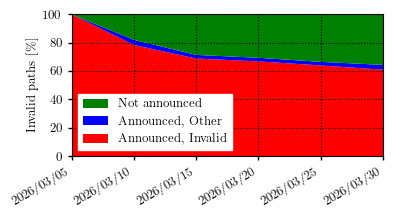

In [ ]:
fastplot.plot(plot_data, None, mode='timeseries_stacked',
              style=plot_style, legend=False, grid=True, fontsize=9,
              ylabel=r'Invalid paths [\%]', ytick_direction='out', # ylim=(0, 1400),
              xticks=[(pd.date_range(start='2026-03-05', end='2026-03-30', freq='5D')), None],
              xtick_direction='out', xticks_rotate=30)

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(
    handles[::-1], labels[::-1], loc='best', ncol=1, fontsize=9, numpoints=1,
    frameon=True, facecolor='white', edgecolor='white', framealpha=1, fancybox=False)

plt.savefig('figures/invalid_paths_over_time.pdf', bbox_inches='tight')

## Do paths no longer Invalid subsequently revert to Invalid?

In [ ]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[df['date'] >= '2026-03-01']
df['customer'] = df['customer'].apply(lambda s: s[2:])
df['providers'] = df['providers'].apply(lambda provs: set(p[2:] for p in provs.split(' ')))

# To monitor only changes to ASPAs of those that were involved in the initial invalid paths
CUSTOMERS = set(df[df['date'] < '2026-03-06']['customer'])
df = df[df['customer'].isin(CUSTOMERS)]

outcomes_per_day = dict()
ASES_THAT_UPDATED_ASPA = set()
prev_period_aspa = dict()

# % of invalid paths that are still invalid
plot_data_invalidity = dict()
for date_str in ('2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30'):
    outcomes_per_day[date_str] = defaultdict(set)
    
    df_part = df[df['date'] <= date_str]
    df_part = df_part.sort_values('date')
    df_part.drop_duplicates('customer', keep='last')
    
    period_aspa = df_part.set_index('customer')['providers'].to_dict()
    period_verifier = ASPAVerifier(period_aspa)

    # ASes whose ASPA changed since the previous period
    if date_str != '2026-03-05':
        changed_asns = {
            asn for asn in set(period_aspa) | set(prev_period_aspa)
            if period_aspa.get(asn) != prev_period_aspa.get(asn)
        }
        ASES_THAT_UPDATED_ASPA |= changed_asns
        
    prev_period_aspa = period_aspa
    
    for path_str in invalid_paths:
        path = path_str.split('|')
        receiver = path[0]
        neighbor = path[1]
        received_path = path[1:]

        outcome = 'Other'
    
        if receiver in period_aspa and neighbor not in period_aspa[receiver]:
            outcome = period_verifier.verify_upstream_path(received_path)
        else:
            o1 = period_verifier.verify_upstream_path(received_path)
            o2 = period_verifier.verify_downstream_path(received_path)

            if o1 == "Invalid" and o2 == "Invalid":
                outcome = "Invalid"
            if o1 == "Valid" and o2 == "Valid":
                outcome = "Other"
            if o1 == "Unknown" and o2 == "Unknown":
                outcome = "Other"

        outcomes_per_day[date_str][outcome].add(path_str)

In [ ]:
# paths that went from Valid back to Invalid
invalid_to_valid_to_invalid = set()
for day1, day2 in zip(
        ['2026-03-05', '2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25'],
        ['2026-03-10', '2026-03-15', '2026-03-20', '2026-03-25', '2026-03-30']
    ):
    invalid_to_valid_to_invalid |= (outcomes_per_day[day1]['Other'] & outcomes_per_day[day2]['Invalid'])

print(invalid_to_valid_to_invalid)

set()
